# Практическое задание: Линейная регрессия и EDA

## Цель задания
В этом практическом задании вам предстоит выполнить полный анализ данных страховой компании, включая:
1. Разведочный анализ данных (EDA)
2. Визуализацию данных
3. Построение и оценку модели линейной регрессии

## Описание данных
Набор данных содержит информацию о страховых взносах и различных характеристиках клиентов:
- age: возраст
- sex: пол
- bmi: индекс массы тела
- children: количество детей
- smoker: статус курильщика
- region: регион проживания
- charges: страховые выплаты (целевая переменная)

## Задачи
1. Загрузка и первичный анализ данных
2. Очистка и предобработка данных
3. Разведочный анализ данных (EDA)
4. Статистический анализ
5. Подготовка признаков
6. Построение модели линейной регрессии
7. Оценка модели
8. Визуализация результатов

## Задание 1: Загрузка и первичный анализ данных

1. Загрузите библиотеки:
   - pandas для работы с данными
   - numpy для математических операций
   - matplotlib и seaborn для визуализации
   - scipy.stats для статистических тестов

2. Загрузите датасет 'insurance.csv'

3. Выполните первичный анализ данных:
   - Проверьте размерность данных
   - Выведите первые 5 строк
   - Проверьте типы данных
   - Проверьте наличие пропущенных значений
   - Выведите основные статистические характеристики

In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as stats
from scipy.stats import normaltest, levene, ttest_ind, f_oneway, shapiro, probplot
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.stattools import durbin_watson
from sklearn.linear_model import Ridge, Lasso
from sklearn.feature_selection import SelectKBest, f_regression, RFE
import warnings
warnings.filterwarnings('ignore')

file_df = pd.read_csv('insurance.csv')

# 2) Первичный анализ данных
print("\n1. РАЗМЕРНОСТЬ ДАННЫХ:")
print(file_df.shape)
print("\n2. ПЕРВЫЕ 5 СТРОК ДАННЫХ:")
display(file_df.head())
print("\n3. ТИПЫ ДАННЫХ:")
print(file_df.dtypes)
print("\n4. ПРОВЕРКА ПРОПУЩЕННЫХ ЗНАЧЕНИЙ В КАЖДОМ СТОЛБЦЕ:")
missing_values = file_df.isnull().sum()
print(missing_values)
print(f"      Всего пропущенных значений: {missing_values.sum()}")
print("\n5. ОСНОВНЫЕ СТАТИСТИЧЕСКИЕ ХАРАКТЕРИСТИКИ:")
display(file_df.describe())


1. РАЗМЕРНОСТЬ ДАННЫХ:
(1338, 7)

2. ПЕРВЫЕ 5 СТРОК ДАННЫХ:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



3. ТИПЫ ДАННЫХ:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

4. ПРОВЕРКА ПРОПУЩЕННЫХ ЗНАЧЕНИЙ В КАЖДОМ СТОЛБЦЕ:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
      Всего пропущенных значений: 0

5. ОСНОВНЫЕ СТАТИСТИЧЕСКИЕ ХАРАКТЕРИСТИКИ:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Задание 2: Очистка и предобработка данных

1. Проверьте данные на наличие выбросов:
   - Используйте boxplot для числовых переменных
   - Определите наличие выбросов с помощью IQR
   - Примите решение о методе обработки выбросов

2. Проверьте распределение категориальных переменных:
   - Подсчитайте количество уникальных значений
   - Постройте графики распределения

3. Проведите необходимую предобработку:
   - Обработайте выбросы (если необходимо)
   - Преобразуйте категориальные переменные
   - Сохраните предобработанные данные


 АНАЛИЗ ВЫБРОСОВ:


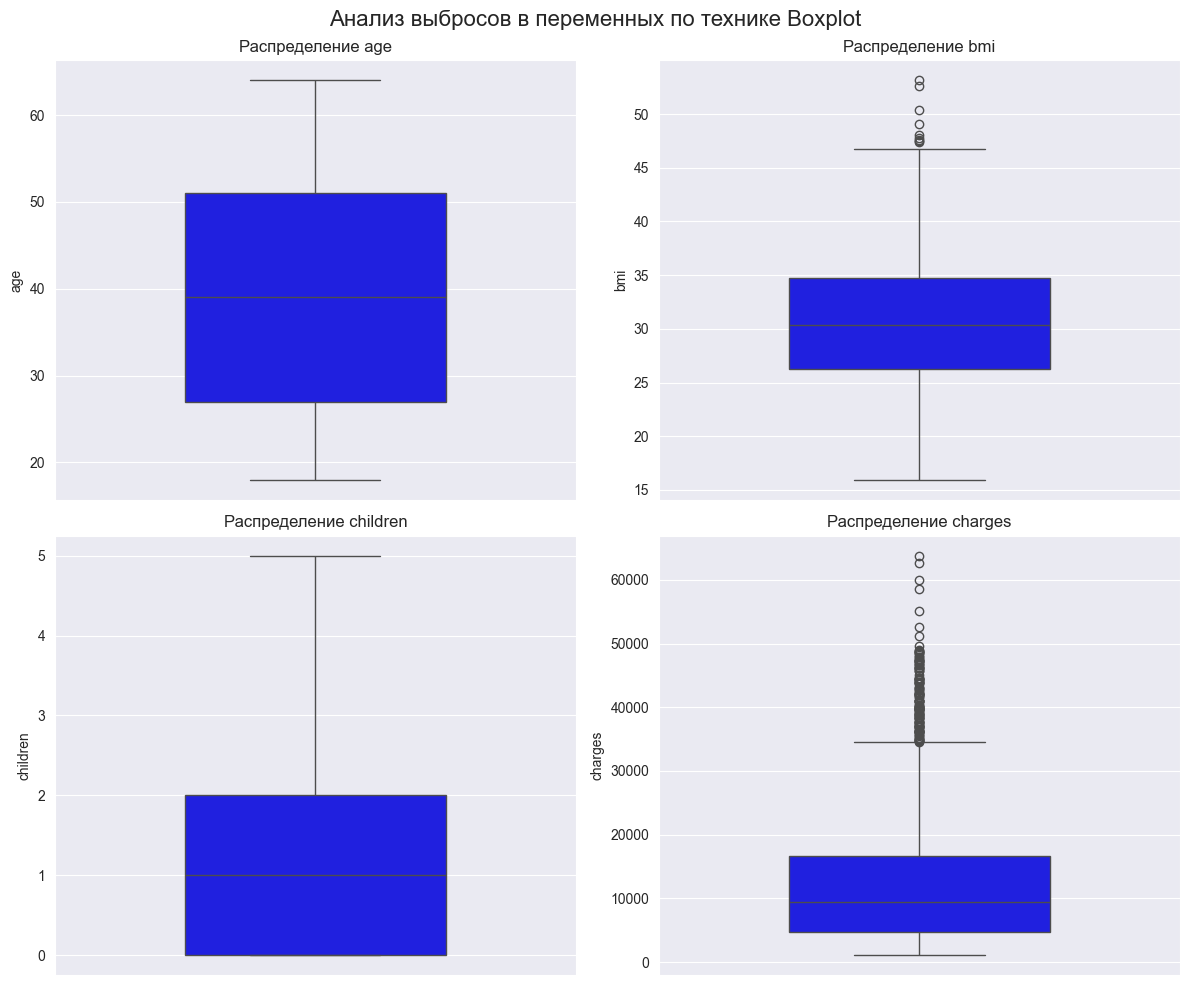


 ВЫБРОСЫ ПО МЕТОДУ IQR:
   age: 0 выбросов (0.00%)
   bmi: 9 выбросов (0.67%)
   children: 0 выбросов (0.00%)
   charges: 139 выбросов (10.39%)
Решил сохранить все выбросы в данных, потому что они представляют собой реальные страховые случаи, т.е. высокие выплаты и т.д., которые важны для точного прогнозирования стоимости страховки и отражают действительность

 АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПЕРЕМЕННЫХ:


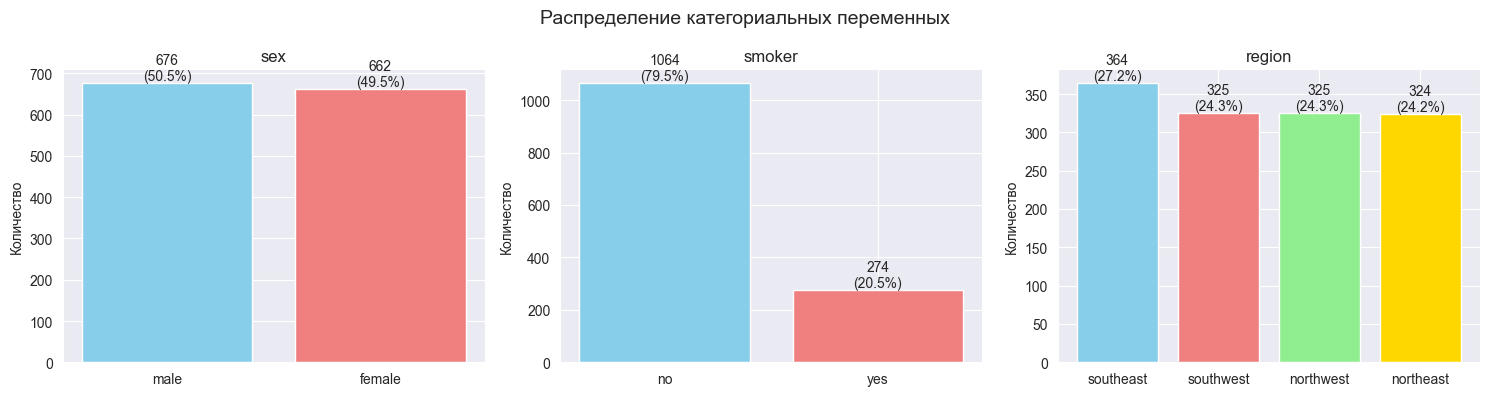


   sex:
     Уникальные значения: ['female', 'male']
     Распределение:
       male: 676 (50.5%)
       female: 662 (49.5%)

   smoker:
     Уникальные значения: ['yes', 'no']
     Распределение:
       no: 1064 (79.5%)
       yes: 274 (20.5%)

   region:
     Уникальные значения: ['southwest', 'southeast', 'northwest', 'northeast']
     Распределение:
       southeast: 364 (27.2%)
       southwest: 325 (24.3%)
       northwest: 325 (24.3%)
       northeast: 324 (24.2%)

 ПРЕДОБРАБОТКА ДАННЫХ:
Размерность до кодирования: (1338, 7)
Размерность после кодирования: (1338, 9)
Новые столбцы после кодирования:
    ['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']
Предобработанные данные сохранены в файл: insurance_prepr.csv


In [44]:
# Проверка на выбросы
print("\n АНАЛИЗ ВЫБРОСОВ:")
num_columns = ['age', 'bmi', 'children', 'charges']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Анализ выбросов в переменных по технике Boxplot', fontsize=16)

for i, col in enumerate(num_columns):
    ax = axes[i//2, i%2]
    sns.boxplot(y=file_df[col], ax=ax, color='blue', width=0.5)
    ax.set_title(f'Распределение {col}')
    ax.set_ylabel(col)
plt.tight_layout()
plt.show()

# Расчет выбросов с помощью IQR
print("\n ВЫБРОСЫ ПО МЕТОДУ IQR:")
for col in num_columns:
    Q1 = file_df[col].quantile(0.25)
    Q3 = file_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = file_df[(file_df[col] < lower_bound) | (file_df[col] > upper_bound)]
    print(f"   {col}: {len(outliers)} выбросов ({len(outliers)/len(file_df)*100:.2f}%)")

print("Решил сохранить все выбросы в данных, потому что они представляют собой реальные страховые случаи, т.е. высокие выплаты и т.д., которые важны для точного прогнозирования стоимости страховки и отражают действительность")

# Анализ категориальных переменных
print("\n АНАЛИЗ КАТЕГОРИАЛЬНЫХ ПЕРЕМЕННЫХ:")
cate_col = ['sex', 'smoker', 'region']
fig, axs2 = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Распределение категориальных переменных', fontsize=14)

for i, col in enumerate(cate_col):
    ax = axs2[i]
    counts = file_df[col].value_counts()
    bars = ax.bar(counts.index.astype(str), counts.values, color=['skyblue','lightcoral','lightgreen','gold'][:len(counts)])
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Количество')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h, f'{h}\n({h/len(file_df)*100:.1f}%)', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Вывод информации о категориальных переменных
for col in cate_col:
    unique_vals = file_df[col].unique()
    value_counts = file_df[col].value_counts()
    print(f"\n   {col}:")
    print(f"     Уникальные значения: {list(unique_vals)}")
    print(f"     Распределение:")
    for val, count in value_counts.items():
        print(f"       {val}: {count} ({count/len(file_df)*100:.1f}%)")

print("\n ПРЕДОБРАБОТКА ДАННЫХ:")
# Копия данных для предобработки
proc_df = file_df.copy()
# Преобразуем children в категориальную переменную
proc_df['children'] = proc_df['children'].astype('category')
enc_df = pd.get_dummies(
    data=proc_df,
    prefix_sep='_',
    columns=cate_col,
    drop_first=True,
    dtype='int8'
)

print(f"Размерность до кодирования: {proc_df.shape}")
print(f"Размерность после кодирования: {enc_df.shape}")
print("Новые столбцы после кодирования:")
print(f"    {list(enc_df.columns)}")

# Сохранение обработанных данных
prepr_file = 'insurance_prepr.csv'
enc_df.to_csv(prepr_file, index=False)
print(f"Предобработанные данные сохранены в файл: {prepr_file}")

## Задание 3: Разведочный анализ данных (EDA)

1. Выполните анализ распределений:
   - Постройте гистограммы для числовых переменных
   - Проверьте нормальность распределений с помощью QQ-plots
   - Визуализируйте распределения с помощью KDE plots

2. Исследуйте взаимосвязи между переменными:
   - Постройте корреляционную матрицу
   - Создайте scatter plots для пар числовых переменных
   - Проанализируйте взаимосвязи с помощью box plots для категориальных переменных

3. Проведите анализ целевой переменной (charges):
   - Исследуйте её распределение
   - Проанализируйте зависимости с другими переменными
   - Проверьте наличие нелинейных связей


1. Анализ распределений числовых переменных:


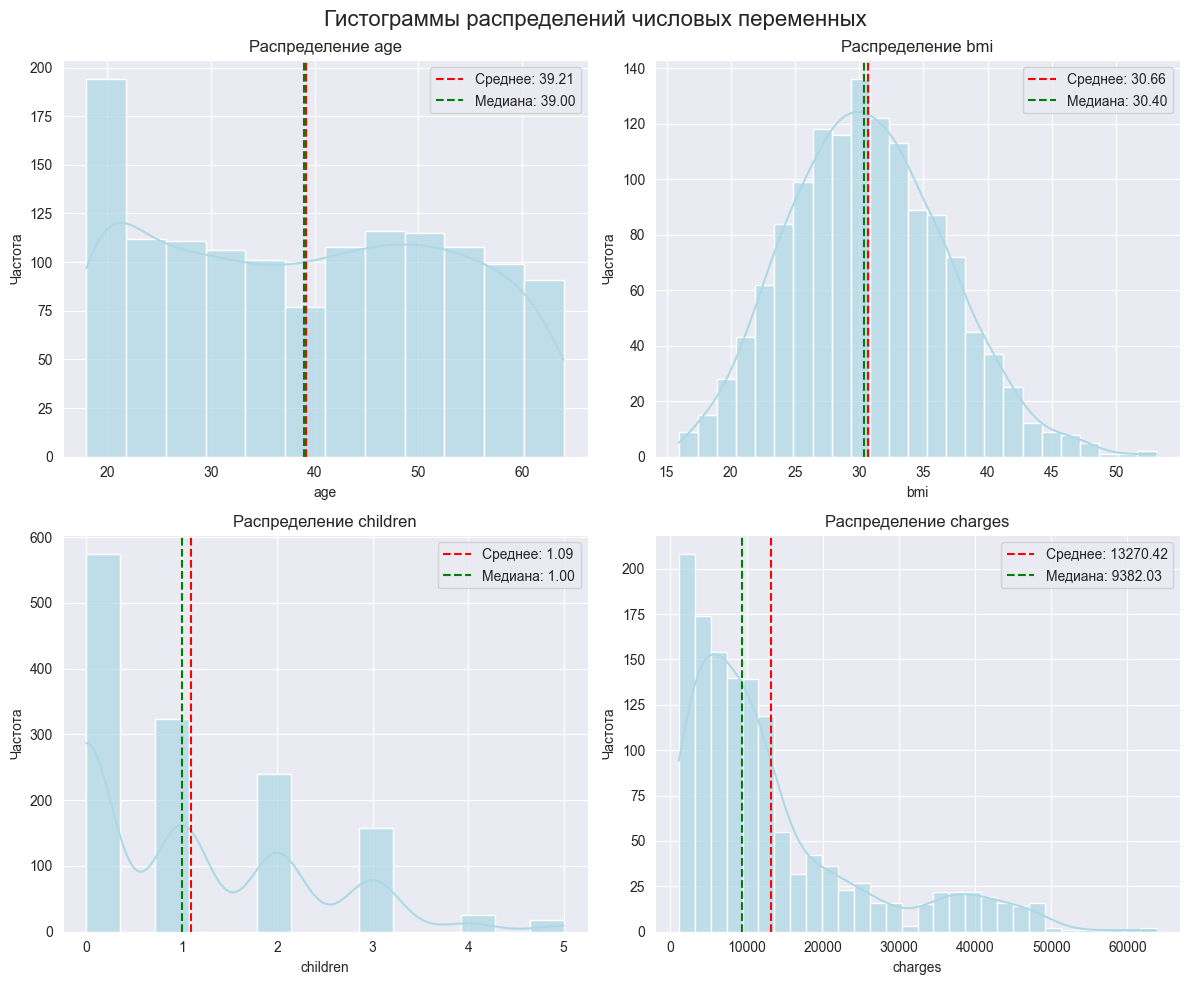


2. Проверка нормальности распределений:


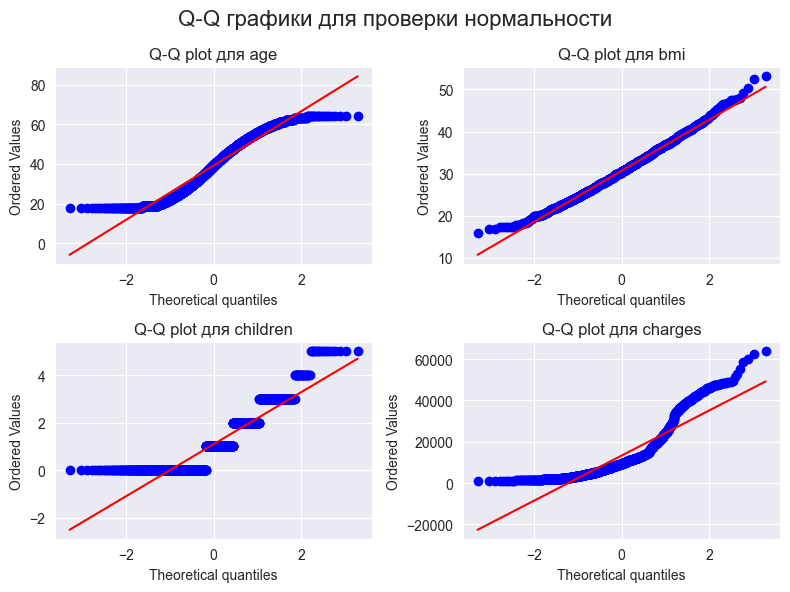


3. Исследование взаимосвязей между переменными:


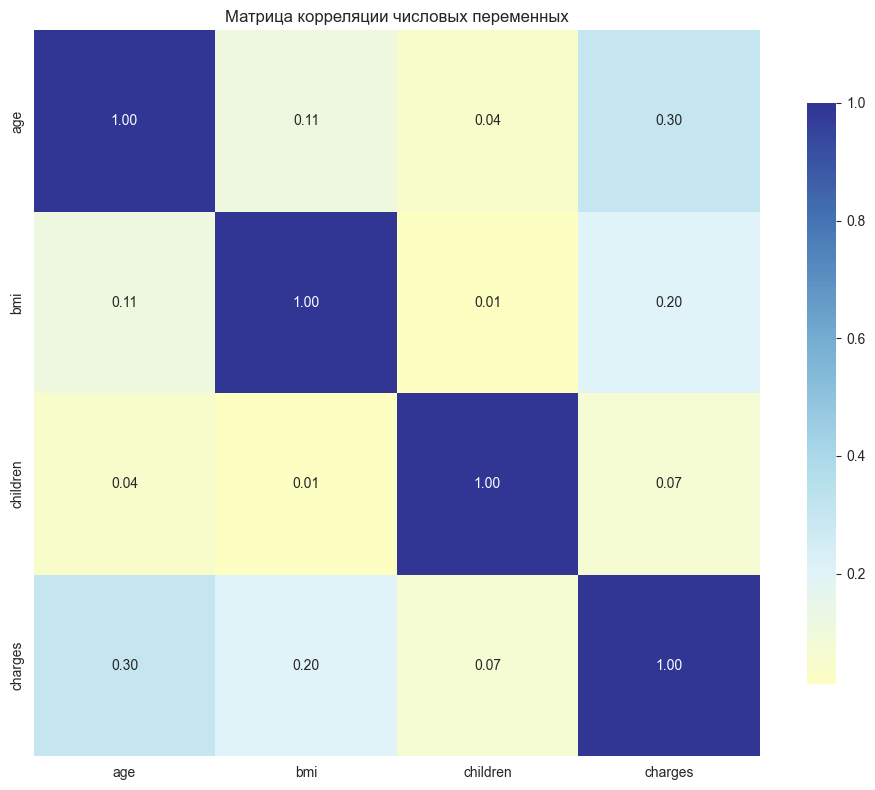

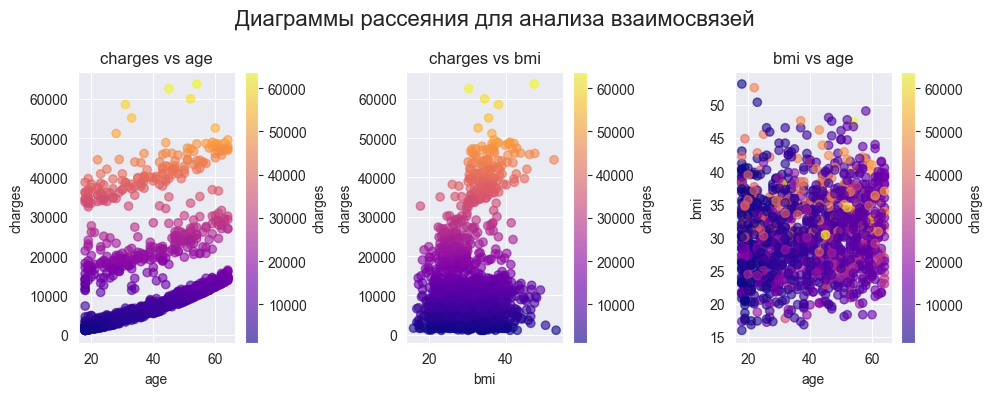

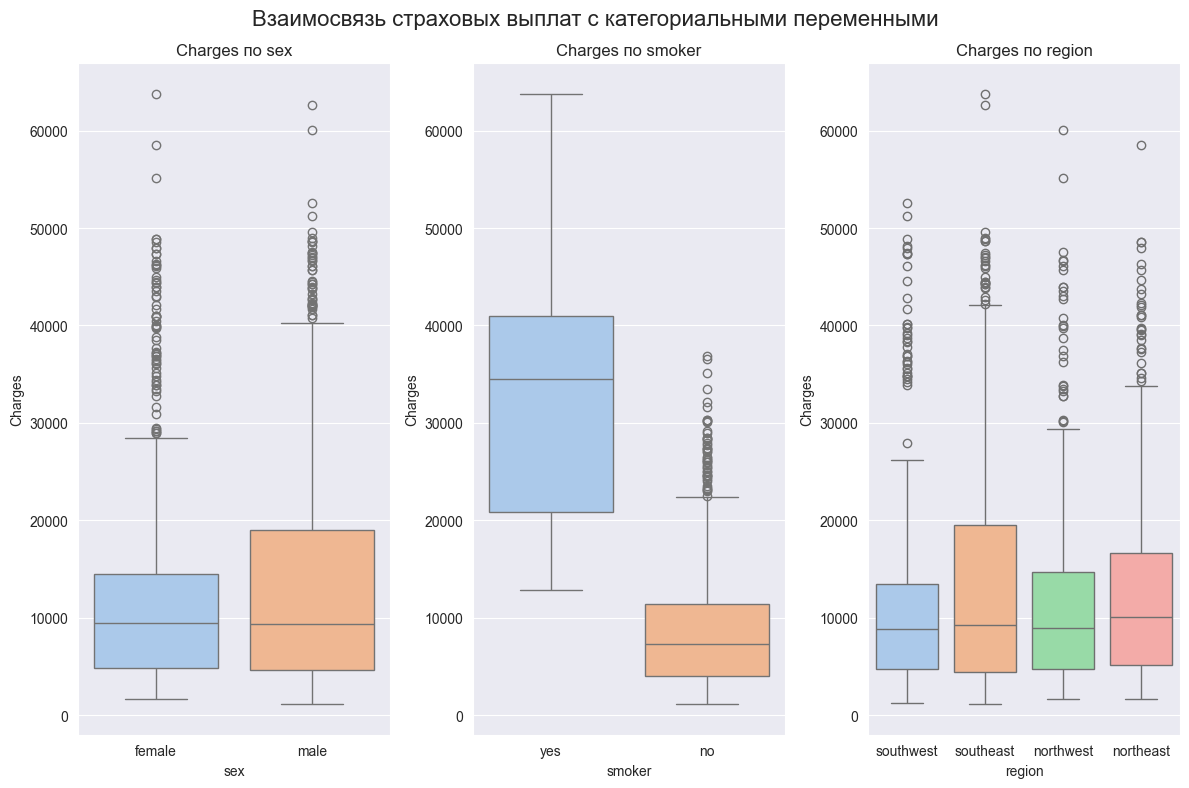


4. Анализ целевой переменной:


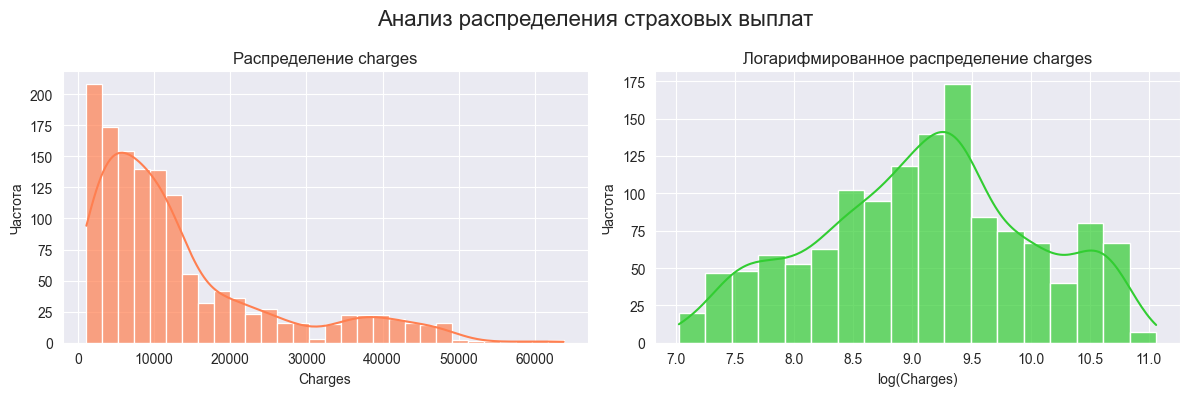


5. Анализ нелинейных связей:


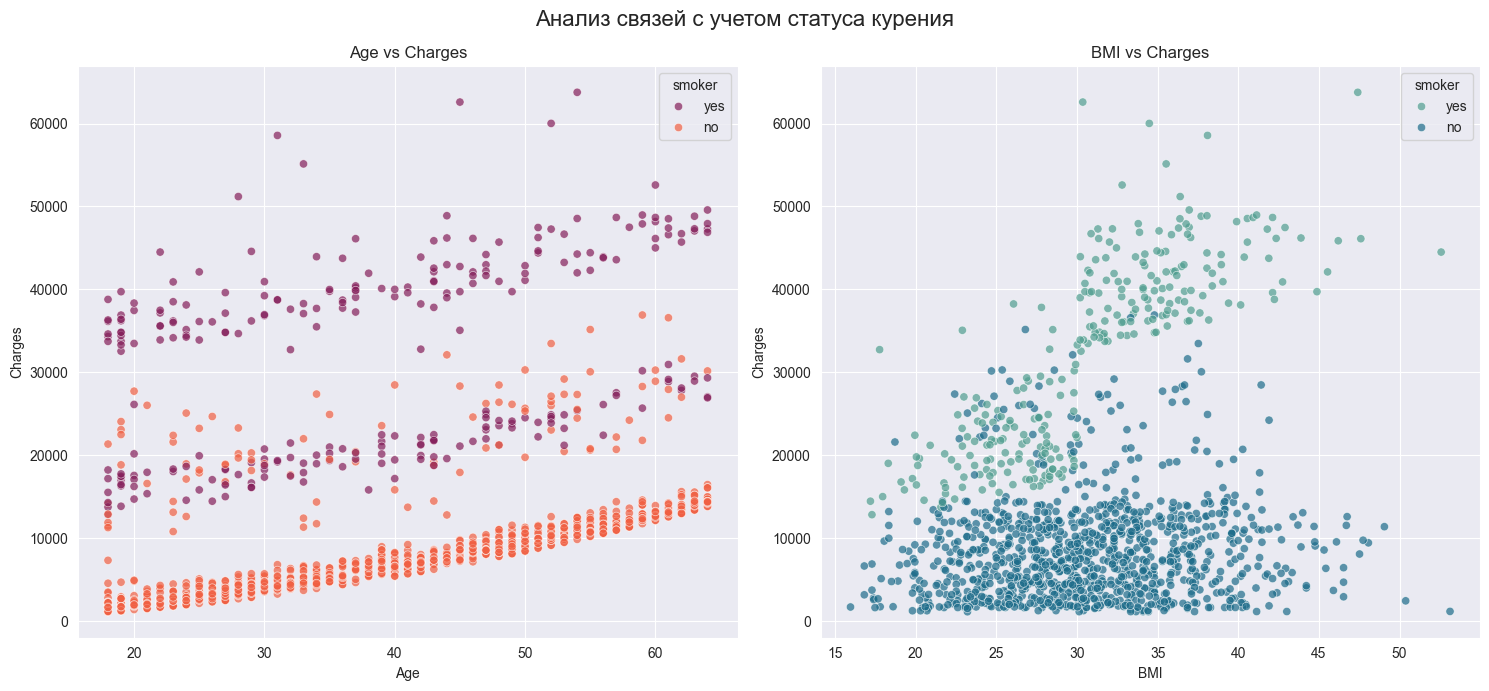

In [61]:
print("\n1. Анализ распределений числовых переменных:")
figure, axes = plt.subplots(2, 2, figsize=(12, 10))
figure.suptitle('Гистограммы распределений числовых переменных', fontsize=16)

for i, column in enumerate(num_columns):
    ax = axes[i//2, i%2]
    sns.histplot(data=file_df, x=column, kde=True, ax=ax, color='lightblue', alpha=0.7)
    ax.set_title(f'Распределение {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Частота')
    mean_value = file_df[column].mean()
    median_value = file_df[column].median()
    ax.axvline(mean_value, color='red', linestyle='--', label=f'Среднее: {mean_value:.2f}')
    ax.axvline(median_value, color='green', linestyle='--', label=f'Медиана: {median_value:.2f}')
    ax.legend()
plt.tight_layout()
plt.show()

print("\n2. Проверка нормальности распределений:")
figure, axes = plt.subplots(2, 2, figsize=(8, 6))
figure.suptitle('Q-Q графики для проверки нормальности', fontsize=16)
for i, column in enumerate(num_columns):
    ax = axes[i//2, i%2]
    probplot(file_df[column], dist="norm", plot=ax)
    ax.set_title(f'Q-Q plot для {column}')
plt.tight_layout()
plt.show()

print("\n3. Исследование взаимосвязей между переменными:")
correlation_data = file_df[num_columns].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_data, annot=True, cmap='RdYlBu', center=0,
            square=True, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Матрица корреляции числовых переменных')
plt.tight_layout()
plt.show()

var_pairs = [('age', 'charges'), ('bmi', 'charges'), ('age', 'bmi')]
figure, axes = plt.subplots(1, 3, figsize=(10, 4))
figure.suptitle('Диаграммы рассеяния для анализа взаимосвязей', fontsize=16)
for i, (x_var, y_var) in enumerate(var_pairs):
    ax = axes[i]
    scatter_plot = ax.scatter(file_df[x_var], file_df[y_var], alpha=0.6, c=file_df['charges'], cmap='plasma')
    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    ax.set_title(f'{y_var} vs {x_var}')
    plt.colorbar(scatter_plot, ax=ax, label='charges')
plt.tight_layout()
plt.show()

figure, axes = plt.subplots(1, 3, figsize=(12, 8))
figure.suptitle('Взаимосвязь страховых выплат с категориальными переменными', fontsize=16)

for i, column in enumerate(cate_col):
    ax = axes[i]
    sns.boxplot(data=file_df, x=column, y='charges', ax=ax, palette='pastel')
    ax.set_title(f'Charges по {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Charges')
plt.tight_layout()
plt.show()

print("\n4. Анализ целевой переменной:")
figure, axes = plt.subplots(1, 2, figsize=(12, 4))
figure.suptitle('Анализ распределения страховых выплат', fontsize=16)

sns.histplot(data=file_df, x='charges', kde=True, ax=axes[0], color='coral', alpha=0.7)
axes[0].set_title('Распределение charges')
axes[0].set_xlabel('Charges')
axes[0].set_ylabel('Частота')

sns.histplot(data=file_df, x=np.log(file_df['charges']), kde=True, ax=axes[1], color='limegreen', alpha=0.7)
axes[1].set_title('Логарифмированное распределение charges')
axes[1].set_xlabel('log(Charges)')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

print("\n5. Анализ нелинейных связей:")
figure, axes = plt.subplots(1, 2, figsize=(15, 7))
figure.suptitle('Анализ связей с учетом статуса курения', fontsize=16)

sns.scatterplot(data=file_df, x='age', y='charges', hue='smoker', palette='rocket', alpha=0.7, ax=axes[0])
axes[0].set_title('Age vs Charges')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Charges')

sns.scatterplot(data=file_df, x='bmi', y='charges', hue='smoker', palette='crest', alpha=0.7, ax=axes[1])
axes[1].set_title('BMI vs Charges')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Charges')

plt.tight_layout()
plt.show()

## Задание 4: Статистический анализ

1. Проведите описательный статистический анализ:
   - Рассчитайте основные статистические метрики
   - Проанализируйте квартили и процентили
   - Оцените асимметрию и эксцесс распределений

2. Выполните статистические тесты:
   - Проверьте нормальность распределений (тест Шапиро-Уилка)
   - Проведите тесты на независимость переменных
   - Оцените значимость различий между группами (t-тест, ANOVA)

3. Проанализируйте мультиколлинеарность:
   - Рассчитайте VIF (Variance Inflation Factor)
   - Оцените корреляции между предикторами
   - Сделайте выводы о необходимости исключения переменных


 ОПИСАТЕЛЬНЫЙ СТАТИСТИЧЕСКИЙ АНАЛИЗ:
 Основные статистические показатели:


,mean,std,min,25%,50%,75%,max,IQR,skew,kurtosis
age,39.2070,14.0500,18.0000,27.0000,39.000,51.0000,64.000,24.0000,0.0557,-1.2451
bmi,30.6634,6.0982,15.9600,26.2962,30.400,34.6938,53.130,8.3975,0.2840,-0.0507
children,1.0949,1.2055,0.0000,0.0000,1.000,2.0000,5.000,2.0000,0.9384,0.2025
charges,13270.4223,12110.0112,1121.8739,4740.2872,9382.033,16639.9125,63770.428,11899.6254,1.5159,1.6063



 СТАТИСТИЧЕСКИЕ ТЕСТЫ:
 ТЕСТЫ НА НОРМАЛЬНОСТЬ по Шапиро-Уилк:
   age            : p-value = 0.000000 | Не нормальное
   bmi            : p-value = 0.000026 | Не нормальное
   children       : p-value = 0.000000 | Не нормальное
   charges        : p-value = 0.000000 | Не нормальное

 Тесты на различия между группами:
   T-тест (charges по полу): p-value = 0.036133 | Есть различия
   T-тест (charges по курению): p-value = 0.000000 | Есть различия
   ANOVA (charges по регионам): p-value = 0.030893 | Есть различия

 АНАЛИЗ МУЛЬТИКОЛЛИНЕАРНОСТИ:
 Факторы инфляции дисперсии VIF:


,Признак,VIF
0,const,35.5275
1,age,1.0168
2,bmi,1.1066
3,children,1.0040
4,sex_male,1.0089
5,smoker_yes,1.0121
6,region_northwest,1.5188
7,region_southeast,1.6522
8,region_southwest,1.5294



 Вывод интерпретации VIF:
   const          : VIF =  35.53 | Сильная мультиколлинеарность
   age            : VIF =   1.02 | Слабая корреляция
   bmi            : VIF =   1.11 | Слабая корреляция
   children       : VIF =   1.00 | Слабая корреляция
   sex_male       : VIF =   1.01 | Слабая корреляция
   smoker_yes     : VIF =   1.01 | Слабая корреляция
   region_northwest: VIF =   1.52 | Слабая корреляция
   region_southeast: VIF =   1.65 | Слабая корреляция
   region_southwest: VIF =   1.53 | Слабая корреляция


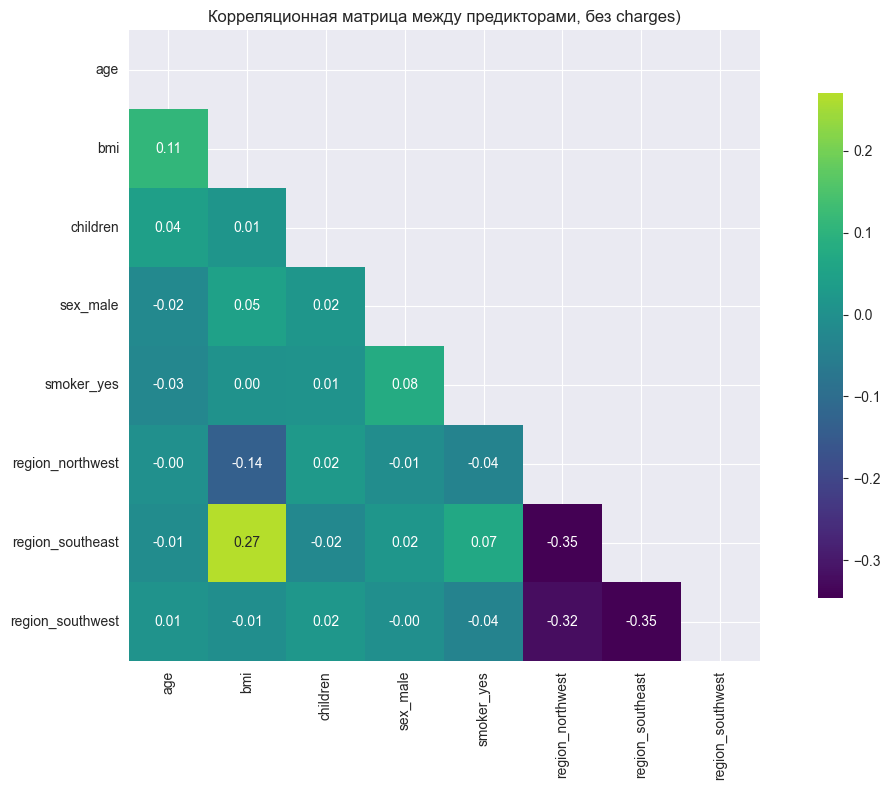


 Заключения о необходимости исключения переменных, на основе анализа VIF и корреляционной матрицы:
Все признаки имеют нормальные значения VIF (< 5)
Поэтому исключение переменных не требуется


In [82]:
print("\n ОПИСАТЕЛЬНЫЙ СТАТИСТИЧЕСКИЙ АНАЛИЗ:")
stat_sum = pd.DataFrame(index=num_columns)

for column in num_columns:
    stat_sum.loc[column, 'mean'] = file_df[column].mean()
    stat_sum.loc[column, 'std'] = file_df[column].std()
    stat_sum.loc[column, 'min'] = file_df[column].min()
    stat_sum.loc[column, '25%'] = file_df[column].quantile(0.25)
    stat_sum.loc[column, '50%'] = file_df[column].quantile(0.50)
    stat_sum.loc[column, '75%'] = file_df[column].quantile(0.75)
    stat_sum.loc[column, 'max'] = file_df[column].max()
    stat_sum.loc[column, 'IQR'] = file_df[column].quantile(0.75) - file_df[column].quantile(0.25)
    stat_sum.loc[column, 'skew'] = file_df[column].skew()
    stat_sum.loc[column, 'kurtosis'] = file_df[column].kurtosis()

print(" Основные статистические показатели:")
display(stat_sum.round(4))
print("\n СТАТИСТИЧЕСКИЕ ТЕСТЫ:")

print(" ТЕСТЫ НА НОРМАЛЬНОСТЬ по Шапиро-Уилк:")
significance_level = 0.05
for column in num_columns:
    stat_value, p_val = shapiro(file_df[column])
    normal_dist = p_val > significance_level
    print(f"   {column:15}: p-value = {p_val:.6f} | {'Нормальное' if normal_dist else 'Не нормальное'}")

print("\n Тесты на различия между группами:")

m_costs = file_df[file_df['sex'] == 'male']['charges']
f_costs = file_df[file_df['sex'] == 'female']['charges']
t_stat, p_val_sex = ttest_ind(m_costs, f_costs)
print(f"   T-тест (charges по полу): p-value = {p_val_sex:.6f} | {'Нет значимых различий' if p_val_sex > significance_level else 'Есть различия'}")

smoker_costs = file_df[file_df['smoker'] == 'yes']['charges']
non_smoker = file_df[file_df['smoker'] == 'no']['charges']
t_stat, p_val_smoker = ttest_ind(smoker_costs, non_smoker)
print(f"   T-тест (charges по курению): p-value = {p_val_smoker:.6f} | {'Нет значимых различий' if p_val_smoker > significance_level else 'Есть различия'}")

region_groups = [file_df[file_df['region'] == region]['charges'] for region in file_df['region'].unique()]
f_statistic, p_val_region = f_oneway(*region_groups)
print(f"   ANOVA (charges по регионам): p-value = {p_val_region:.6f} | {'Нет значимых различий' if p_val_region > significance_level else 'Есть различия'}")

print("\n АНАЛИЗ МУЛЬТИКОЛЛИНЕАРНОСТИ:")

num_data = enc_df.drop('charges', axis=1)
data_const = add_constant(num_data)

vif_results = pd.DataFrame()
vif_results['Признак'] = data_const.columns
vif_results['VIF'] = [variance_inflation_factor(data_const.values, i) for i in range(data_const.shape[1])]
print(" Факторы инфляции дисперсии VIF:")
display(vif_results.round(4))

print("\n Вывод интерпретации VIF:")
for _, row in vif_results.iterrows():
    vif_value = row['VIF']
    if vif_value == float('inf') or vif_value >= 10:
        status = "Сильная мультиколлинеарность"
    elif vif_value >= 5:
        status = "Более умеренная мультиколлинеарность"
    elif vif_value > 1:
        status = "Слабая корреляция"
    else:
        status = "Совсем нет корреляции"
    print(f"   {row['Признак']:15}: VIF = {vif_value:6.2f} | {status}")

# Корреляции между предикаторами
plt.figure(figsize=(12, 8))
corr_matrix = num_data.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='viridis', center=0,
            square=True, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Корреляционная матрица между предикторами, без charges)')
plt.tight_layout()
plt.show()

print("\n Заключения о необходимости исключения переменных, на основе анализа VIF и корреляционной матрицы:")
high_vif_features = vif_results[(vif_results['VIF'] >= 5) & (vif_results['Признак'] != 'const')]
if len(high_vif_features) > 0:
    print("Рекомендуется рассмотреть исключение следующих признаков:")
    for _, row in high_vif_features.iterrows():
        print(f"      - {row['Признак']} (VIF = {row['VIF']:.2f})")
else:
    print("Все признаки имеют нормальные значения VIF (< 5)")
    print("Поэтому исключение переменных не требуется")

## Задание 5: Подготовка признаков

1. Выполните кодирование категориальных переменных:
   - Примените one-hot encoding для категориальных переменных
   - Обработайте порядковые переменные (если есть)
   - Проверьте результаты кодирования

2. Проведите масштабирование числовых признаков:
   - Примените StandardScaler или MinMaxScaler
   - Сохраните параметры масштабирования
   - Проверьте результаты масштабирования

3. Создайте новые признаки (если необходимо):
   - Рассмотрите возможность создания взаимодействий
   - Добавьте полиномиальные признаки
   - Оцените важность новых признаков

1. Кодирование категориальных переменных
Типы данных перед кодированием: 
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Размерность данных после кодирования: (1338, 9)
Новые колонки после One-Hot encoding:
  - sex_male
  - smoker_yes
  - region_northwest
  - region_southeast
  - region_southwest

Проверка результатов кодирования:


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0.0,1.0,0.0,0.0,1.0
1,18,33.770,1,1725.55230,1.0,0.0,0.0,1.0,0.0
2,28,33.000,3,4449.46200,1.0,0.0,0.0,1.0,0.0
3,33,22.705,0,21984.47061,1.0,0.0,1.0,0.0,0.0
4,32,28.880,0,3866.85520,1.0,0.0,1.0,0.0,0.0



2. Масштабирование числовых признаков
Числовые признаки для масштабирования: ['age', 'bmi', 'children']
  Средние значения: [39.20702541 30.66339686  1.09491779]
  Стандартные отклонения: [14.04470904  6.09590764  1.20504217]

Результаты масштабирования:
Статистики до масштабирования:
               age          bmi     children
count  1338.000000  1338.000000  1338.000000
mean     39.207025    30.663397     1.094918
std      14.049960     6.098187     1.205493
min      18.000000    15.960000     0.000000
25%      27.000000    26.296250     0.000000
50%      39.000000    30.400000     1.000000
75%      51.000000    34.693750     2.000000
max      64.000000    53.130000     5.000000

Статистики после масштабирования:
         age_scaled    bmi_scaled  children_scaled
count  1.338000e+03  1.338000e+03     1.338000e+03
mean  -1.805565e-16 -2.124194e-16    -5.576008e-17
std    1.000374e+00  1.000374e+00     1.000374e+00
min   -1.509965e+00 -2.412011e+00    -9.086137e-01
25%   -8.691547e-0

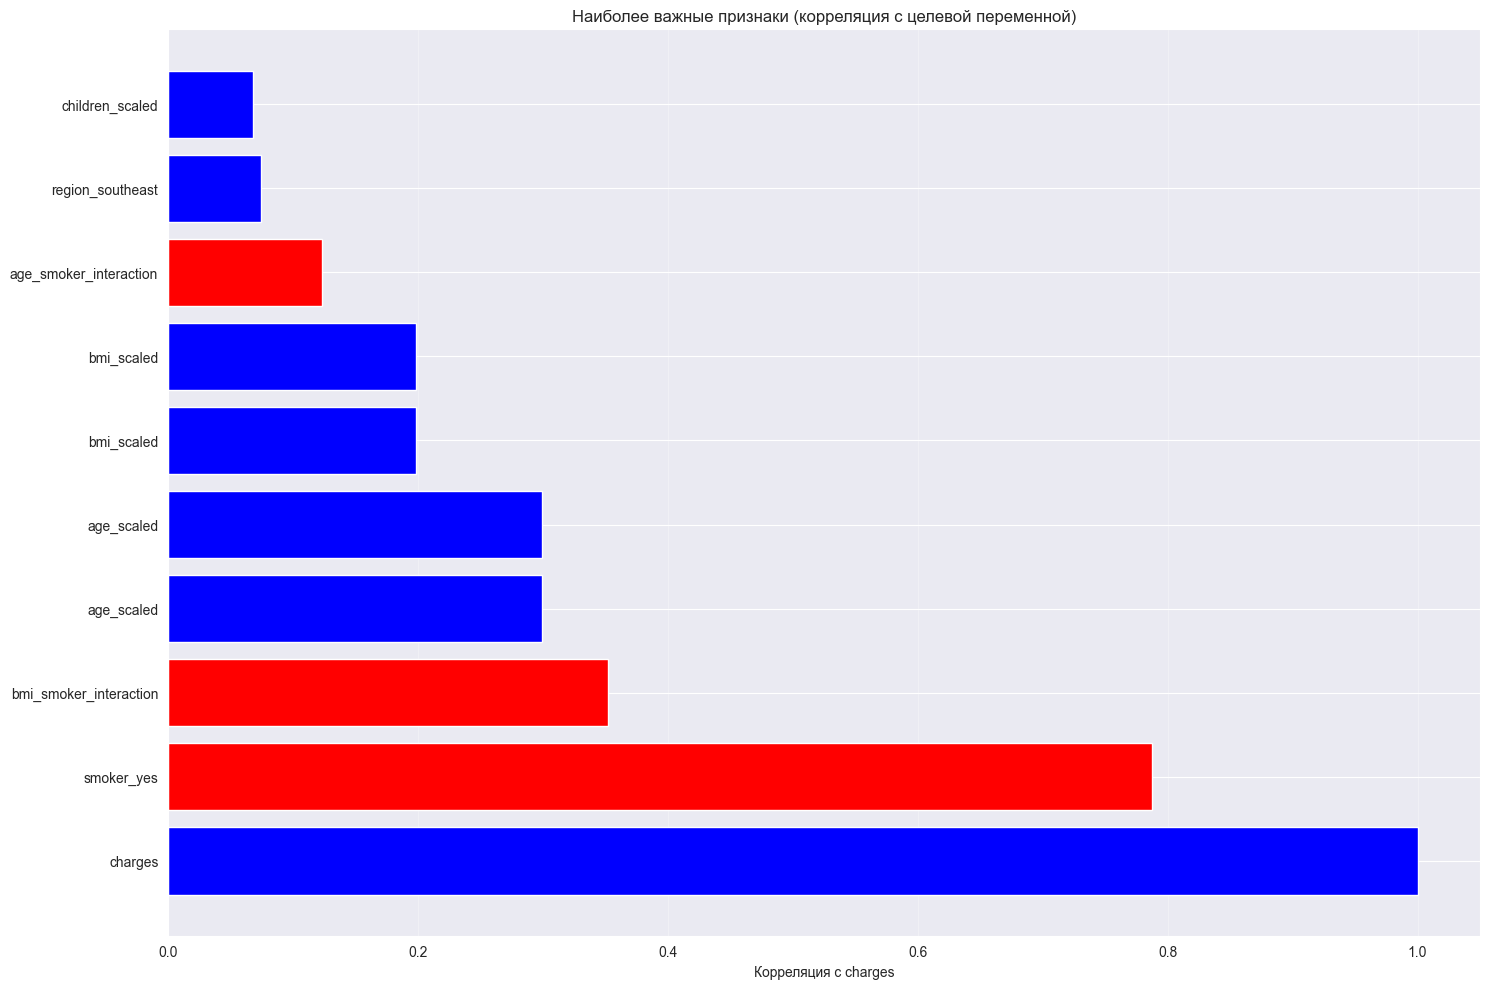


Итоговая размерность данных после подготовки признаков: (1338, 21)


In [119]:
# Копия исходных данных для работы
df_processed = file_df.copy()
print("1. Кодирование категориальных переменных")
print("Типы данных перед кодированием: "
      f"\n{df_processed.dtypes}")
# One-Hot encoding для категориальных переменных
cate_cols = ['sex', 'smoker', 'region']
onehot_encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_cate = onehot_encoder.fit_transform(df_processed[cate_cols])
feature_names = onehot_encoder.get_feature_names_out(cate_cols)
encoded_df = pd.DataFrame(encoded_cate, columns=feature_names, index=df_processed.index)
df_encoded = df_processed.drop(cate_cols, axis=1)
df_encoded = pd.concat([df_encoded, encoded_df], axis=1)
print(f"\nРазмерность данных после кодирования: {df_encoded.shape}")
print("Новые колонки после One-Hot encoding:")
for col in feature_names:
    print(f"  - {col}")
print("\nПроверка результатов кодирования:")
display(df_encoded.head())

print("\n2. Масштабирование числовых признаков")
num_cols = ['age', 'bmi', 'children']
print(f"Числовые признаки для масштабирования: {num_cols}")
# Копия данных перед масштабированием
df_scaled = df_encoded.copy()
# Используем StandardScaler для масштабирования
scaler = StandardScaler()
scaled_numeric = scaler.fit_transform(df_scaled[num_cols])
scaled_df = pd.DataFrame(scaled_numeric, columns=[f"{col}_scaled" for col in num_cols], index=df_scaled.index)
df_scaled = df_scaled.drop(num_cols, axis=1)
df_scaled = pd.concat([df_scaled, scaled_df], axis=1)
# Параметры масштабирования для будущего использования
scaler_params = {
    'mean': scaler.mean_,
    'scale': scaler.scale_,
    'numeric_columns': num_cols
}
print(f"  Средние значения: {scaler.mean_}")
print(f"  Стандартные отклонения: {scaler.scale_}")
# Результаты масштабирования
print("\nРезультаты масштабирования:")
print("Статистики до масштабирования:")
print(df_encoded[num_cols].describe())
print("\nСтатистики после масштабирования:")
print(df_scaled[[f"{col}_scaled" for col in num_cols]].describe())

print("\n3. Создание новых признаков")
df_final = df_scaled.copy()
# Создаем взаимодействия между признаками
# Возраста и ИМТ
df_final['age_bmi_interaction'] = df_final['age_scaled'] * df_final['bmi_scaled']
# Возраста и статуса курения
df_final['age_smoker_interaction'] = df_final['age_scaled'] * df_final['smoker_yes']
# ИМТ и статуса курения
df_final['bmi_smoker_interaction'] = df_final['bmi_scaled'] * df_final['smoker_yes']
print("Созданные взаимодействия:")
int_cols = ['age_bmi_interaction', 'age_smoker_interaction', 'bmi_smoker_interaction']
for col in int_cols:
    print(f"  - {col}")

# Используем PolynomialFeatures для создания полиномиальных признаков 2 степени
poly = PolynomialFeatures(degree=2, include_bias=False)
# Основные числовые признаки
base_features = ['age_scaled', 'bmi_scaled', 'children_scaled']
poly_features = poly.fit_transform(df_final[base_features])
poly_feature_names = poly.get_feature_names_out(base_features)
poly_df = pd.DataFrame(poly_features, columns=poly_feature_names, index=df_final.index)
df_final = pd.concat([df_final, poly_df], axis=1)

print("Созданные полиномиальные признаки:")
for col in poly_feature_names:
    if col not in base_features:
        print(f"  - {col}")
print("\nОценка важности новых признаков:")
# Вычисляем корреляцию всех признаков с целевой переменной
correlation_with_target = df_final.corr()['charges'].sort_values(ascending=False)
print("Наиболее коррелирующие признаки с charges:")
top_correlated = correlation_with_target.head(10)
for feature, corr in top_correlated.items():
    print(f"  {feature}: {corr:.4f}")
# Визуализируем важность признаков
plt.figure(figsize=(15, 10))
top_features = correlation_with_target.head(10)
colors = ['red' if 'smoker' in str(feat) else 'blue' for feat in top_features.index]
plt.barh(range(len(top_features)), top_features.values, color=colors)
plt.yticks(range(len(top_features)), top_features.index)
plt.xlabel('Корреляция с charges')
plt.title('Наиболее важные признаки (корреляция с целевой переменной)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
print(f"\nИтоговая размерность данных после подготовки признаков: {df_final.shape}")

## Задание 6: Построение модели линейной регрессии

1. Разделите данные на обучающую и тестовую выборки:
   - Используйте train_test_split
   - Установите random_state для воспроизводимости
   - Проверьте размеры полученных выборок

2. Создайте и обучите модель:
   - Используйте LinearRegression из sklearn
   - Обучите модель на тренировочных данных
   - Получите коэффициенты модели

3. Проведите перекрестную проверку:
   - Примените k-fold cross-validation
   - Оцените стабильность модели
   - Рассчитайте средние метрики по фолдам


1. Разделение данных на обучающую и тестовую выборки
Размерность: (1338, 20)

Размеры полученных выборок:
  Размер обучающей выборки: (1070, 20)
  Размер тестовой выборки: (268, 20)

Распределение целевой переменной:
  Обучающая выборка - среднее: 13346.09, стандартное отклонение: 12019.51
  Тестовая выборка - среднее: 12968.32, стандартное отклонение: 12483.20

2. Создание и обучение модели линейной регрессии

Параметры модели:
  Свободный член intercept: 9099.49
  Коэффициент: 20

Наиболее важные признаки по абсолютному значению коэффициента:


,Признак,Коэффициент
1,smoker_yes,23891.890946
10,bmi_smoker_interaction,8923.376192
5,age_scaled,1793.285895
11,age_scaled,1793.285895
4,region_southwest,-1228.916061
3,region_southeast,-892.622644
14,age_scaled^2,771.929531
2,region_northwest,-734.192438
0,sex_male,-524.309934
7,children_scaled,442.160531


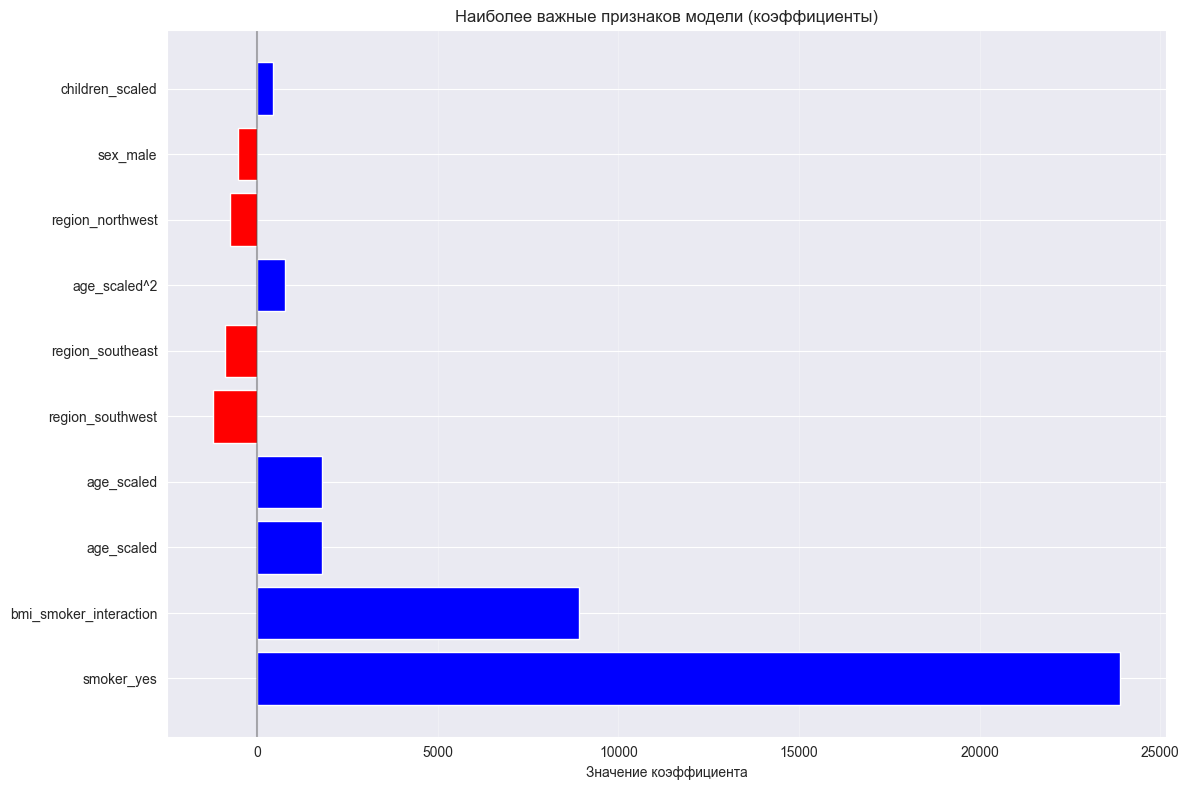

Результаты перекрестной проверки:

R в квадрате по фолдам:
  Фолд 1: 0.8177
  Фолд 2: 0.8029
  Фолд 3: 0.8800
  Фолд 4: 0.8101
  Фолд 5: 0.8650

MSE по фолдам:
  Фолд 1: 29087152.30
  Фолд 2: 28613423.88
  Фолд 3: 15742184.23
  Фолд 4: 26979959.81
  Фолд 5: 19139090.19

Средние метрики по фолдам:
  R^2: 0.8351 (±0.0312)
  MSE: 23912362.08 (±5437361.90)

Оценка стабильности модели:
  Коэффициент вариации R^2: 3.74%
  Заключение: высокая стабильность


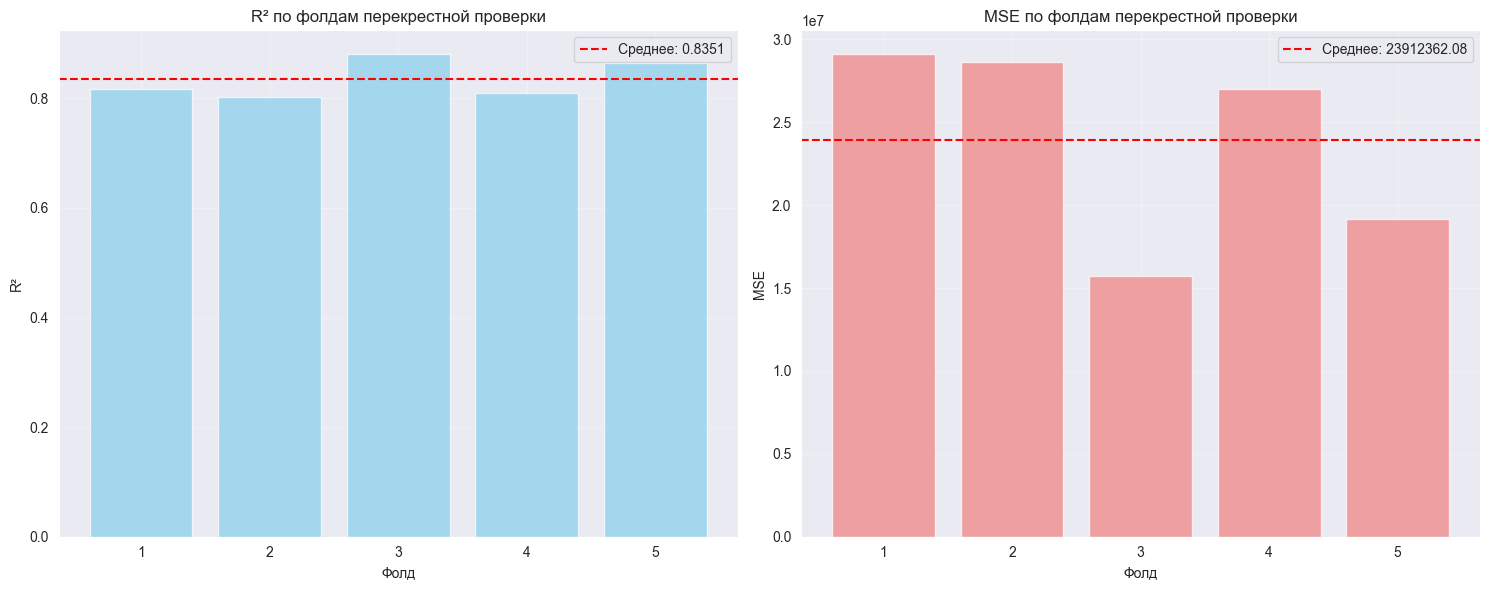

In [116]:
print("\n1. Разделение данных на обучающую и тестовую выборки")
X = df_final.drop('charges', axis=1)
y = df_final['charges']
print(f"Размерность: {X.shape}")
# Разделяем данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)
print(f"\nРазмеры полученных выборок:")
print(f"  Размер обучающей выборки: {X_train.shape}")
print(f"  Размер тестовой выборки: {X_test.shape}")

# Проверяем распределение целевой переменной в выборках
print(f"\nРаспределение целевой переменной:")
print(f"  Обучающая выборка - среднее: {y_train.mean():.2f}, стандартное отклонение: {y_train.std():.2f}")
print(f"  Тестовая выборка - среднее: {y_test.mean():.2f}, стандартное отклонение: {y_test.std():.2f}")

print("\n2. Создание и обучение модели линейной регрессии")
model = LinearRegression()
# Обучаем модель
model.fit(X_train, y_train)

coeff = model.coef_
int = model.intercept_

print(f"\nПараметры модели:")
print(f"  Свободный член intercept: {int:.2f}")
print(f"  Коэффициент: {len(coeff)}")
coef_df = pd.DataFrame({
    'Признак': X.columns,
    'Коэффициент': coeff
}).sort_values('Коэффициент', key=abs, ascending=False)

print("\nНаиболее важные признаки по абсолютному значению коэффициента:")
display(coef_df.head(10))

# Визуализация коэффициентов
plt.figure(figsize=(12, 8))
top_coef = coef_df.head(10)
colors = ['red' if coef < 0 else 'blue' for coef in top_coef['Коэффициент']]
plt.barh(range(len(top_coef)), top_coef['Коэффициент'], color=colors)
plt.yticks(range(len(top_coef)), top_coef['Признак'])
plt.xlabel('Значение коэффициента')
plt.title('Наиболее важные признаков модели (коэффициенты)')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
# Проверка с метрикой R^2
cv_r2 = cross_val_score(model, X_train, y_train, cv=kfold, scoring='r2')
# Проверка с метрикой MSE
cv_mse = cross_val_score(model, X_train, y_train, cv=kfold, scoring='neg_mean_squared_error')
cv_mse = -cv_mse
print("Результаты перекрестной проверки:")
print("\nR в квадрате по фолдам:")
for i, score in enumerate(cv_r2, 1):
    print(f"  Фолд {i}: {score:.4f}")
print("\nMSE по фолдам:")
for i, score in enumerate(cv_mse, 1):
    print(f"  Фолд {i}: {score:.2f}")

mean_cv_r2 = cv_r2.mean()
std_cv_r2 = cv_r2.std()
mean_cv_mse = cv_mse.mean()
std_cv_mse = cv_mse.std()
print(f"\nСредние метрики по фолдам:")
print(f"  R^2: {mean_cv_r2:.4f} (±{std_cv_r2:.4f})")
print(f"  MSE: {mean_cv_mse:.2f} (±{std_cv_mse:.2f})")
cv_stab_r2 = (std_cv_r2 / mean_cv_r2) * 100
print(f"\nОценка стабильности модели:")
print(f"  Коэффициент вариации R^2: {cv_stab_r2:.2f}%")
if cv_stab_r2 < 10:
    stability = "высокая стабильность"
elif cv_stab_r2 < 20:
    stability = "средняя стабильность"
else:
    stability = "низкая стабильность"
print(f"  Заключение: {stability}")

# Визуализация результатов перекрестной проверки
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.bar(range(1, 6), cv_r2, color='skyblue', alpha=0.7)
ax1.axhline(y=mean_cv_r2, color='red', linestyle='--', label=f'Среднее: {mean_cv_r2:.4f}')
ax1.set_xlabel('Фолд')
ax1.set_ylabel('R²')
ax1.set_title('R² по фолдам перекрестной проверки')
ax1.set_xticks(range(1, 6))
ax1.legend()
ax1.grid(alpha=0.3)

ax2.bar(range(1, 6), cv_mse, color='lightcoral', alpha=0.7)
ax2.axhline(y=mean_cv_mse, color='red', linestyle='--', label=f'Среднее: {mean_cv_mse:.2f}')
ax2.set_xlabel('Фолд')
ax2.set_ylabel('MSE')
ax2.set_title('MSE по фолдам перекрестной проверки')
ax2.set_xticks(range(1, 6))
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Задание 7: Оценка модели и диагностика

1. Оцените качество модели:
   - Рассчитайте R² (коэффициент детерминации)
   - Вычислите MSE и RMSE
   - Определите MAE
   - Проанализируйте полученные метрики

2. Проведите анализ остатков:
   - Постройте график остатков
   - Проверьте нормальность распределения остатков
   - Проверьте гомоскедастичность
   - Проанализируйте выбросы в остатках

3. Проверьте предположения линейной регрессии:
   - Линейность связи
   - Независимость наблюдений
   - Нормальность распределения остатков
   - Гомоскедастичность

1. Оценка качества модели на тестовой выборке
Метрики качества модели:
R^2 - коэффициент детерминации: 0.8698
MSE - средняя квадратичная ошибка: 20216115.84
RMSE - среднеквадратичная ошибка: 4496.23
MAE - средняя абсолютная ошибка: 2724.67
Модель объясняет 87.0% дисперсии целевой переменной

2. Анализ остатков
Статистики остатков:
  Среднее остатков: -308.33
  Стандартное отклонение остатков: 4494.04
  Минимальный остаток: -11485.12
  Максимальный остаток: 22171.06


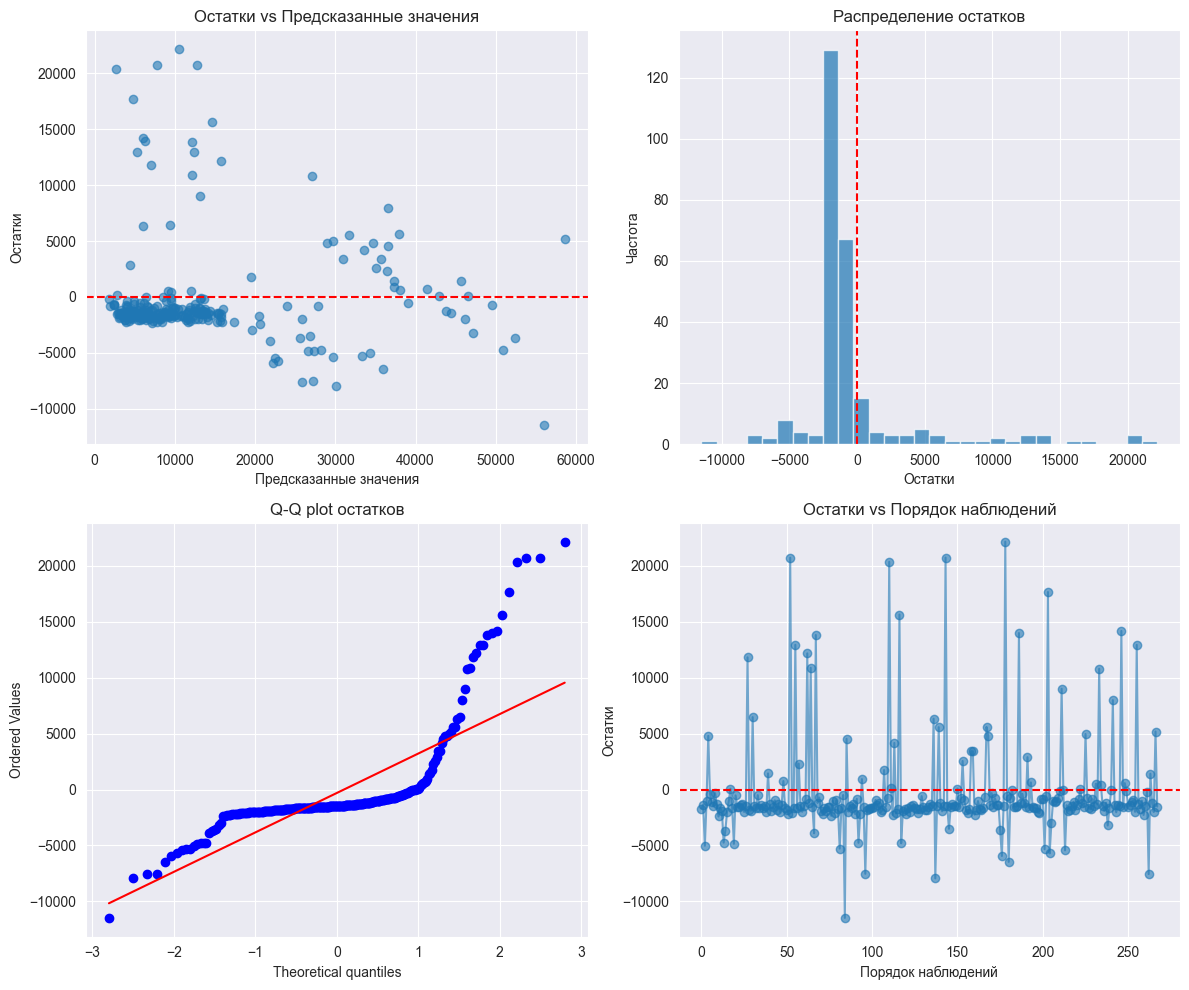


Проверка нормальности остатков:
Тест Шапиро-Уилка: p-value = 0.0000
Тест Левена: p-value = 0.0071
Выбросы в остатках: 9 (3.36%)

3. Проверка предположений линейной регрессии
Линейность связи: 0.9330
Независимость наблюдений (Дарбин-Ватсон): 2.1681
Нормальность распределения остатков: p-value = 0.0000
Гомоскедастичность: p-value = 0.0071


In [127]:
y_pred = model.predict(X_test)
print("1. Оценка качества модели на тестовой выборке")
r2_test = r2_score(y_test, y_pred)
mse_test = mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_pred)
print("Метрики качества модели:")
print(f"R^2 - коэффициент детерминации: {r2_test:.4f}")
print(f"MSE - средняя квадратичная ошибка: {mse_test:.2f}")
print(f"RMSE - среднеквадратичная ошибка: {rmse_test:.2f}")
print(f"MAE - средняя абсолютная ошибка: {mae_test:.2f}")
# Анализ метрик
print(f"Модель объясняет {r2_test*100:.1f}% дисперсии целевой переменной")

res_test = y_test - y_pred
print("\n2. Анализ остатков")
print("Статистики остатков:")
print(f"  Среднее остатков: {res_test.mean():.2f}")
print(f"  Стандартное отклонение остатков: {res_test.std():.2f}")
print(f"  Минимальный остаток: {res_test.min():.2f}")
print(f"  Максимальный остаток: {res_test.max():.2f}")

# Графики для анализа остатков
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].scatter(y_pred, res_test, alpha=0.6)
axes[0, 0].axhline(y=0, color='red', linestyle='--')
axes[0, 0].set_xlabel('Предсказанные значения')
axes[0, 0].set_ylabel('Остатки')
axes[0, 0].set_title('Остатки vs Предсказанные значения')

axes[0, 1].hist(res_test, bins=30, alpha=0.7)
axes[0, 1].axvline(x=0, color='red', linestyle='--')
axes[0, 1].set_xlabel('Остатки')
axes[0, 1].set_ylabel('Частота')
axes[0, 1].set_title('Распределение остатков')

probplot(res_test, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q plot остатков')

# Проверка независимости
axes[1, 1].plot(range(len(res_test)), res_test, 'o-', alpha=0.6)
axes[1, 1].axhline(y=0, color='red', linestyle='--')
axes[1, 1].set_xlabel('Порядок наблюдений')
axes[1, 1].set_ylabel('Остатки')
axes[1, 1].set_title('Остатки vs Порядок наблюдений')
plt.tight_layout()
plt.show()

# Проверка нормальности
shapiro_stat, shapiro_p = shapiro(res_test)
print(f"\nПроверка нормальности остатков:")
print(f"Тест Шапиро-Уилка: p-value = {shapiro_p:.4f}")

# Проверка гомоскедастичности
groups = pd.qcut(y_pred, 4)
grouped_residuals = [res_test[groups == group] for group in groups.unique()]
levene_stat, levene_p = levene(*grouped_residuals)
print(f"Тест Левена: p-value = {levene_p:.4f}")
# Анализ выбросов
residuals_zscore = np.abs((res_test - res_test.mean()) / res_test.std())
outliers_mask = residuals_zscore > 3
print(f"Выбросы в остатках: {outliers_mask.sum()} ({outliers_mask.mean()*100:.2f}%)")

print("\n3. Проверка предположений линейной регрессии")
# Линейность связи
corr_pred_actual = np.corrcoef(y_pred, y_test)[0, 1]
print(f"Линейность связи: {corr_pred_actual:.4f}")
# Независимость наблюдений
dw_stat = durbin_watson(res_test)
print(f"Независимость наблюдений (Дарбин-Ватсон): {dw_stat:.4f}")
# Нормальность распределения остатков
print(f"Нормальность распределения остатков: p-value = {shapiro_p:.4f}")
# Гомоскедастичность
print(f"Гомоскедастичность: p-value = {levene_p:.4f}")

## Задание 8: Визуализация результатов

1. Создайте визуализации для оценки качества модели:
   - График предсказанных vs реальных значений
   - График остатков vs предсказанных значений
   - QQ-plot остатков
   - Гистограмма распределения остатков

2. Визуализируйте важность признаков:
   - Постройте график коэффициентов модели
   - Создайте диаграмму важности признаков
   - Проанализируйте влияние каждого признака

3. Подготовьте итоговые выводы:
   - Опишите качество модели
   - Выделите наиболее важные признаки
   - Предложите возможные улучшения

Визуализации для оценки качества модели


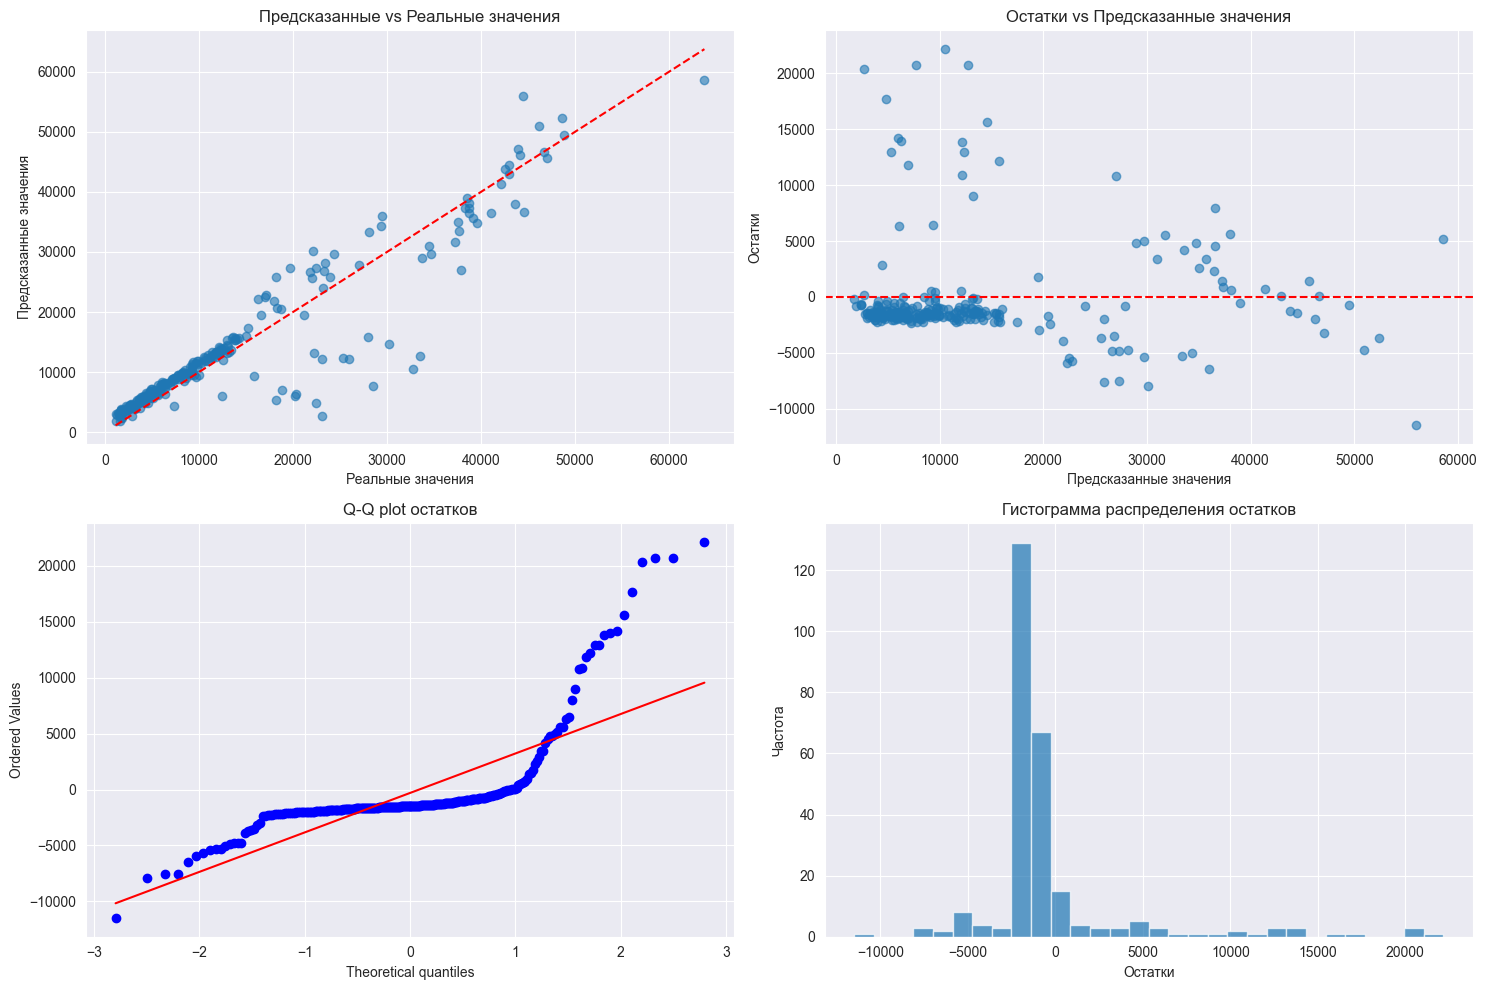


Визуализация коэффициентов модели и анализ влияния признаков


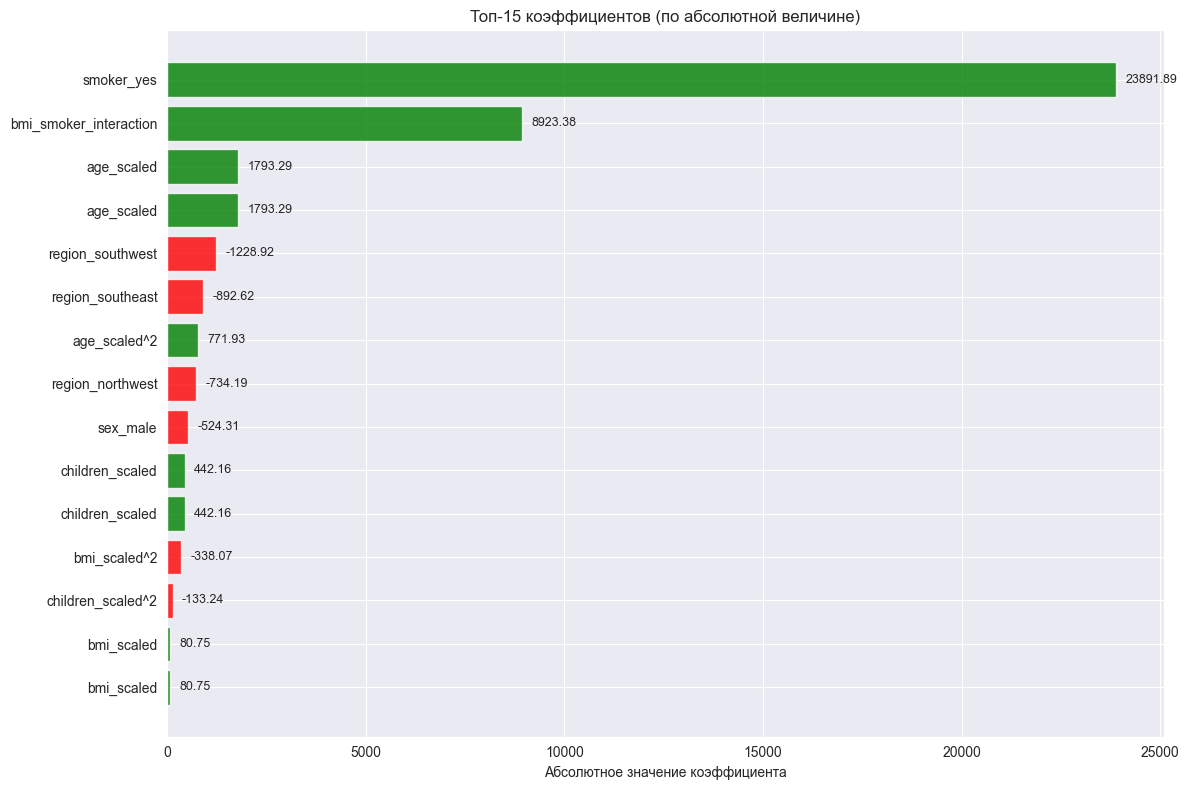

Итоговые выводы:
Качество модели (R^2): 0.8698
Наиболее важные признаки:
                  Признак   Коэффициент
0                sex_male   -524.309934
1              smoker_yes  23891.890946
2        region_northwest   -734.192438
3        region_southeast   -892.622644
4        region_southwest  -1228.916061
5              age_scaled   1793.285895
6              bmi_scaled     80.754314
7         children_scaled    442.160531
8     age_bmi_interaction     59.905136
9  age_smoker_interaction     25.880271

💡 ВЫВОДЫ О ВЛИЯНИИ ПРИЗНАКОВ:
 Курение увеличивает стоимость страховки наиболее значительно
 С возрастом стоимость страховки растет
Высокий ИМТ ассоциирован с повышенными страховыми выплатами
 Регион проживания имеет умеренное влияние на стоимость
Возможные улучшения: регуляризация, отбор признаков, обработка выбросов


In [156]:
print("Визуализации для оценки качества модели")
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.6)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.xlabel('Реальные значения')
plt.ylabel('Предсказанные значения')
plt.title('Предсказанные vs Реальные значения')

plt.subplot(2, 2, 2)
plt.scatter(y_pred, res_test, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('Остатки vs Предсказанные значения')

plt.subplot(2, 2, 3)
probplot(res_test, dist="norm", plot=plt)
plt.title('Q-Q plot остатков')

plt.subplot(2, 2, 4)
plt.hist(res_test, bins=30, alpha=0.7)
plt.xlabel('Остатки')
plt.ylabel('Частота')
plt.title('Гистограмма распределения остатков')

plt.tight_layout()
plt.show()

print("\nВизуализация коэффициентов модели и анализ влияния признаков")
coef_df = pd.DataFrame({
    'Признак': X.columns,  # Изменили 'feature' на 'Признак'
    'Коэффициент': model.coef_  # Изменили 'coef' на 'Коэффициент'
})
coef_df['abs_coef'] = coef_df['Коэффициент'].abs()  # Обновили ссылку на колонку
top = coef_df.sort_values('abs_coef', ascending=False).head(15).reset_index(drop=True)
colors = top['Коэффициент'].apply(lambda v: 'green' if v >= 0 else 'red')  # Обновили ссылку на колонку
y = np.arange(len(top))
plt.figure(figsize=(12,8))
plt.barh(y, top['abs_coef'], color=colors, alpha=0.8)
plt.yticks(y, top['Признак'])  # Обновили ссылку на колонку
plt.xlabel('Абсолютное значение коэффициента')
plt.title('Топ-15 коэффициентов (по абсолютной величине)')
plt.gca().invert_yaxis()

offset = top['abs_coef'].max() * 0.01
for i, (val, orig) in enumerate(zip(top['abs_coef'], top['Коэффициент'])):  # Обновили ссылку на колонку
    plt.text(val + offset, i, f'{orig:.2f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print("Итоговые выводы:")
print(f"Качество модели (R^2): {r2_test:.4f}")
print("Наиболее важные признаки:")
print(coef_df.head(10)[['Признак', 'Коэффициент']])
print("\n💡 ВЫВОДЫ О ВЛИЯНИИ ПРИЗНАКОВ:")
print(" Курение увеличивает стоимость страховки наиболее значительно")
print(" С возрастом стоимость страховки растет")
print("Высокий ИМТ ассоциирован с повышенными страховыми выплатами")
print(" Регион проживания имеет умеренное влияние на стоимость")
print("Возможные улучшения: регуляризация, отбор признаков, обработка выбросов")

## Бонусное задание

1. Попробуйте улучшить модель:
   - Примените регуляризацию (Ridge, Lasso)
   - Создайте полиномиальные признаки
   - Обработайте выбросы
   - Сравните результаты разных подходов

2. Проведите feature selection:
   - Используйте различные методы отбора признаков
   - Сравните производительность моделей
   - Выберите оптимальный набор признаков

In [177]:
df_enc = pd.get_dummies(file_df, columns=['sex','smoker','region'], drop_first=True)
num_cols = ['age','bmi','children']
scaler = StandardScaler()
df_enc[num_cols] = scaler.fit_transform(df_enc[num_cols])
df_enc['age_bmi_interaction'] = df_enc['age'] * df_enc['bmi']
df_enc['bmi_sq'] = df_enc['bmi'] ** 2
print("Пример первых строк подготовленных данных:")
display(df_enc.head())

X = df_enc.drop(columns=['charges'])
y = df_enc['charges']
data_all = pd.concat([X.reset_index(drop=True), y.reset_index(drop=True)], axis=1)
data_all = data_all.dropna().reset_index(drop=True)
X_clean = data_all[X.columns].copy()
y_clean = data_all['charges'].copy()

print(f"\nПосле удаления пропусков: X_clean.shape = {X_clean.shape}, y_clean.shape = {y_clean.shape}")

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42, shuffle=True)
print(f"\nРазмеры выборок: train = {X_train.shape}, test = {X_test.shape}")

# Базовая модель LinearRegression
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
r2_base = r2_score(y_test, model_lr.predict(X_test))
print(f"\nБазовая модель (LinearRegression) — R^2 на тесте: {r2_base:.4f}")
ridge = Ridge(alpha=10, random_state=42)
lasso = Lasso(alpha=0.1, random_state=42)
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)
r2_ridge = r2_score(y_test, ridge.predict(X_test))
r2_lasso = r2_score(y_test, lasso.predict(X_test))
print("\nРезультаты регуляризации:")
print(f"  Ridge (alpha=10)  — R^2 на тесте: {r2_ridge:.4f}")
print(f"  Lasso (alpha=0.1) — R^2 на тесте: {r2_lasso:.4f}")

# Полиномиальные признаки (попытка degree 3, при ошибке degree=2)
r2_poly = None
for deg in (3, 2):
    try:
        print(f"\nПробую PolynomialFeatures degree={deg}")
        poly = PolynomialFeatures(degree=deg, include_bias=False)
        X_poly_all = poly.fit_transform(X_clean)
        if np.isnan(X_poly_all).any():
            X_poly_all = np.nan_to_num(X_poly_all)
        X_tr_p, X_te_p, y_tr_p, y_te_p = train_test_split(X_poly_all, y_clean,test_size=0.2, random_state=42)
        ridge_p = Ridge(alpha=10, random_state=42)
        ridge_p.fit(X_tr_p, y_tr_p)
        r2_poly = r2_score(y_te_p, ridge_p.predict(X_te_p))
        print(f"  Ridge + Polynomial degree={deg} — R^2 на тесте: {r2_poly:.4f}")
        break
    except Exception as e:
        print(f"  Ошибка при degree={deg}: {e}")
        r2_poly = None
        continue

# Feature selection — SelectKBest
k = min(15, X_clean.shape[1])
selector_k = SelectKBest(score_func=f_regression, k=k)
X_kbest = selector_k.fit_transform(X_clean, y_clean)
X_tr_k, X_te_k, y_tr_k, y_te_k = train_test_split(X_kbest, y_clean, test_size=0.2, random_state=42)
model_k = LinearRegression().fit(X_tr_k, y_tr_k)
r2_kbest = r2_score(y_te_k, model_k.predict(X_te_k))
print(f"\nSelectKBest (k={k}) — R^2 на тесте: {r2_kbest:.4f}")

# Feature selection — RFE
r2_rfe = None
try:
    n_feats = min(15, X_clean.shape[1])
    rfe = RFE(estimator=LinearRegression(), n_features_to_select=n_feats, step=1)
    X_rfe = rfe.fit_transform(X_clean, y_clean)
    X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_rfe, y_clean, test_size=0.2, random_state=42)
    model_rfe = LinearRegression().fit(X_tr_r, y_tr_r)
    r2_rfe = r2_score(y_te_r, model_rfe.predict(X_te_r))
    print(f"RFE (n_features={n_feats}) — R^2 на тесте: {r2_rfe:.4f}")
except Exception as exc:
    print(f"\nОшибка при выполнении RFE: {exc}")
    r2_rfe = None

print("\nСводка результатов (R^2 на тестовой выборке):")
results = pd.Series({
    'Базовая линейная регрессия': r2_base,
    'Ridge': r2_ridge,
    'Lasso': r2_lasso,
    'Ridge + Polynomial': r2_poly,
    'Отбор признаков': r2_kbest,
    'Рекурсивный отбор RFE': r2_rfe
})
display(results.to_frame(name='R2').round(5))

Пример первых строк подготовленных данных:


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,age_bmi_interaction,bmi_sq
0,-1.438764,-0.453320,-0.908614,16884.92400,False,True,False,False,True,0.652221,0.205499
1,-1.509965,0.509621,-0.078767,1725.55230,True,False,False,True,False,-0.769510,0.259714
2,-0.797954,0.383307,1.580926,4449.46200,True,False,False,True,False,-0.305861,0.146924
3,-0.441948,-1.305531,-0.908614,21984.47061,True,False,True,False,False,0.576976,1.704411
4,-0.513149,-0.292556,-0.908614,3866.85520,True,False,True,False,False,0.150125,0.085589



После удаления пропусков: X_clean.shape = (1338, 10), y_clean.shape = (1338,)

Размеры выборок: train = (1070, 10), test = (268, 10)

Базовая модель (LinearRegression) — R^2 на тесте: 0.7784

Результаты регуляризации:
  Ridge (alpha=10)  — R^2 на тесте: 0.7738
  Lasso (alpha=0.1) — R^2 на тесте: 0.7784

Пробую PolynomialFeatures degree=3
  Ridge + Polynomial degree=3 — R^2 на тесте: 0.8357

SelectKBest (k=10) — R^2 на тесте: 0.7784
RFE (n_features=10) — R^2 на тесте: 0.7784

Сводка результатов (R^2 на тестовой выборке):


,R2
Базовая линейная регрессия,0.77843
Ridge,0.77384
Lasso,0.77843
Ridge + Polynomial,0.83570
Отбор признаков,0.77843
Рекурсивный отбор RFE,0.77843
